# Exploring optimal solutions based on weighted sum of objectives (abiotic anomaly, biotic anomaly, implementation cost)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

# Import restoration optimization modules
from data_loader import load_initial_conditions
from resto_anom import restoration_effect

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
import sys
import io
from contextlib import redirect_stdout
# Quiet data loading function
def load_initial_conditions_quietly(*args, **kwargs):
    """Load initial conditions without printing output to console."""
    f = io.StringIO()
    with redirect_stdout(f):
        result = load_initial_conditions(*args, **kwargs)
    return result

print("✓ Imports completed")

✓ Imports completed


# Look at initial conditions

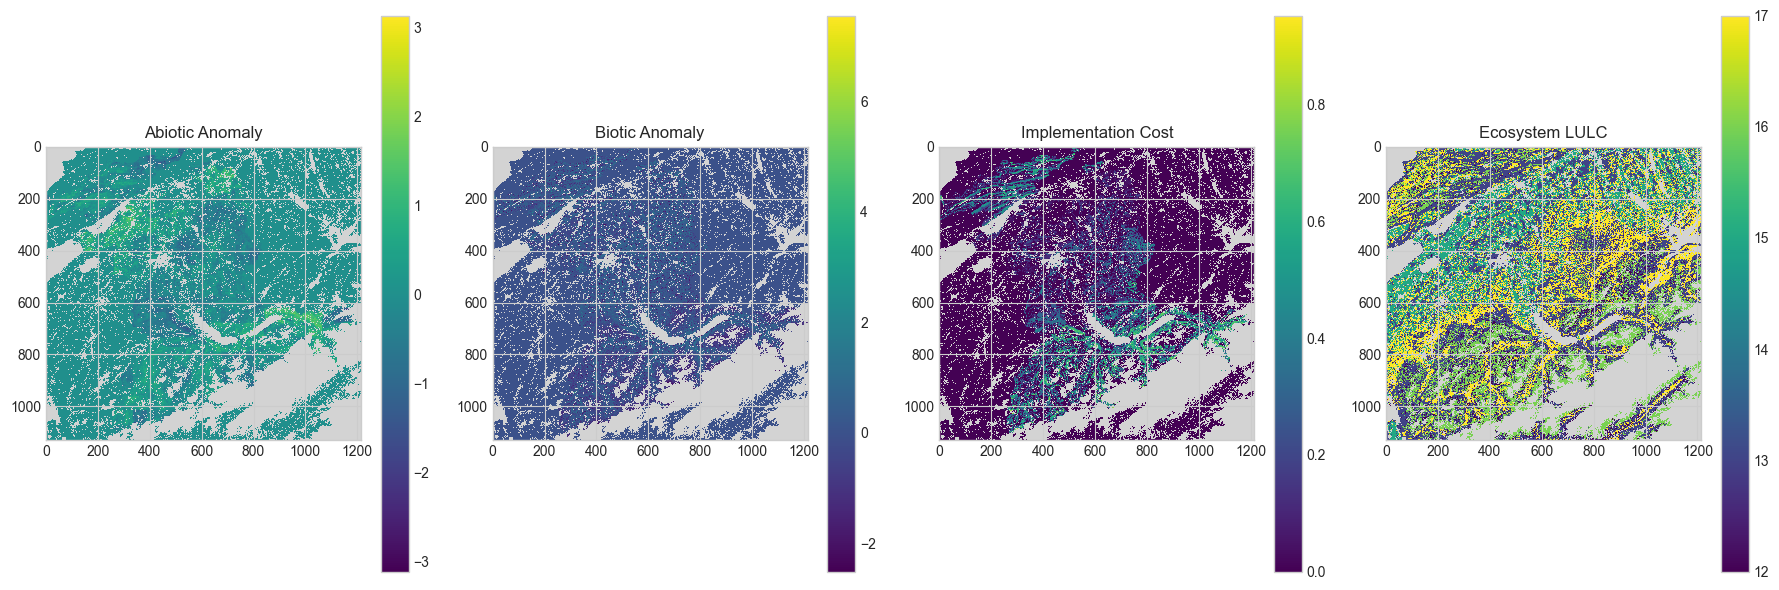

In [2]:
# Plot initial_conditions
initial_conditions = load_initial_conditions_quietly('.', objectives=['abiotic', 'biotic', 'cost'], ecosystem_lulc_path="W:/EU_BioES_SELINA/WP3/4. Spatially_Explicit_EC/Data/LULC/LULC_2018_agg.tif")
# mask to correct LULC values for ecosystem types
ecosystem_lulc = initial_conditions['ecosystem_lulc_data']
masked_conditions = {}
for k in ["abiotic_anomaly", "biotic_anomaly", "implementation_cost", "ecosystem_lulc_data"]:
    masked_conditions[k] = np.where(np.isin(ecosystem_lulc, [12, 13, 15, 16, 17]), initial_conditions[k], np.nan)
    
def plot_raster(data, title, ax):
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color="lightgray")
    cax = ax.imshow(data, cmap=cmap, interpolation='none')
    # Add non-NaN count to title
    ax.set_title(title)
    plt.colorbar(cax, ax=ax)
    
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
plot_raster(masked_conditions['abiotic_anomaly'], 'Abiotic Anomaly', axes[0])
plot_raster(masked_conditions['biotic_anomaly'], 'Biotic Anomaly', axes[1])
plot_raster(masked_conditions['implementation_cost'], 'Implementation Cost', axes[2])
plot_raster(masked_conditions['ecosystem_lulc_data'], 'Ecosystem LULC', axes[3])
plt.tight_layout()
plt.show()

In [3]:
#normalise the initial conditions (min-max normalisation)
normalised_conditions = {}
for k in ["abiotic_anomaly", "biotic_anomaly", "implementation_cost"]:
    a = masked_conditions[k]
    a_min = np.nanmin(a)
    a_max = np.nanmax(a)
    if a_max > a_min:
        normalised_conditions[k] = (a - a_min) / (a_max - a_min)
    else:
        normalised_conditions[k] = np.zeros_like(a)

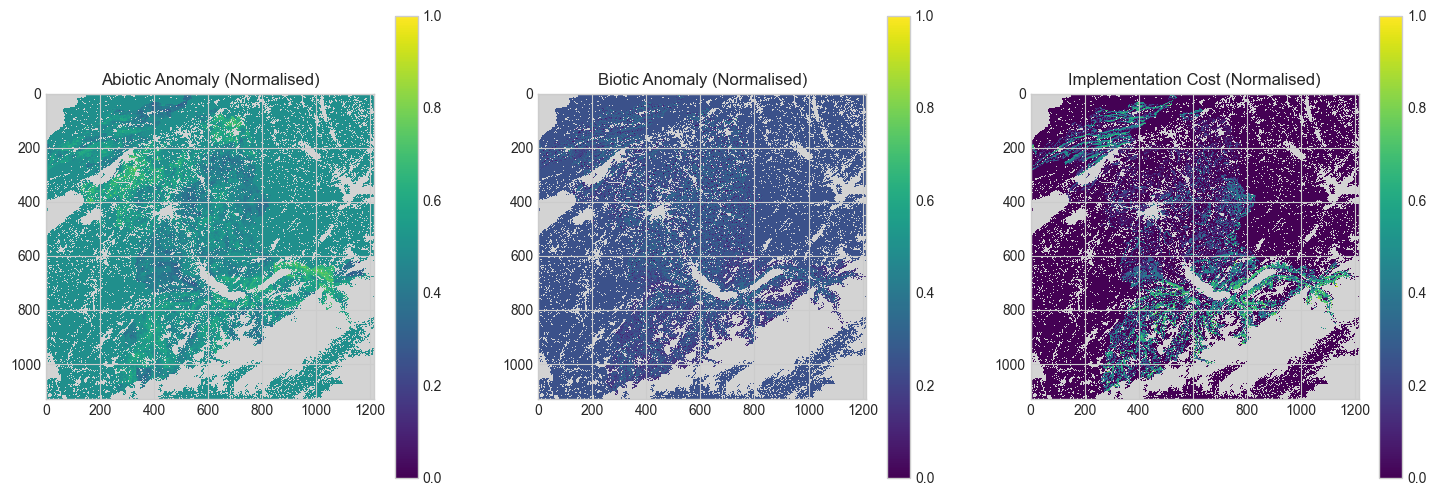

In [4]:
#plot normalised conditions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_raster(normalised_conditions['abiotic_anomaly'], 'Abiotic Anomaly (Normalised)', axes[0])
plot_raster(normalised_conditions['biotic_anomaly'], 'Biotic Anomaly (Normalised)', axes[1])
plot_raster(normalised_conditions['implementation_cost'], 'Implementation Cost (Normalised)', axes[2])

# Create list of weight combinations

In [5]:
step = 0.2

values = np.arange(0, 1 + step, step)

rows = [
    (a, b, round(1 - a - b, 1))
    for a in values
    for b in values
    if 0 <= round(1 - a - b, 10) <= 1
]

weights = pd.DataFrame(rows, columns=["W1", "W2", "W3"])
weights["W3"] = weights["W3"].replace(-0.0, 0.0)
print(weights)

     W1   W2   W3
0   0.0  0.0  1.0
1   0.0  0.2  0.8
2   0.0  0.4  0.6
3   0.0  0.6  0.4
4   0.0  0.8  0.2
5   0.0  1.0  0.0
6   0.2  0.0  0.8
7   0.2  0.2  0.6
8   0.2  0.4  0.4
9   0.2  0.6  0.2
10  0.2  0.8  0.0
11  0.4  0.0  0.6
12  0.4  0.2  0.4
13  0.4  0.4  0.2
14  0.4  0.6  0.0
15  0.6  0.0  0.4
16  0.6  0.2  0.2
17  0.6  0.4  0.0
18  0.8  0.0  0.2
19  0.8  0.2  0.0
20  1.0  0.0  0.0


# For each combination of weights, calculate the value per cell as a weighted sum of the normalised conditions

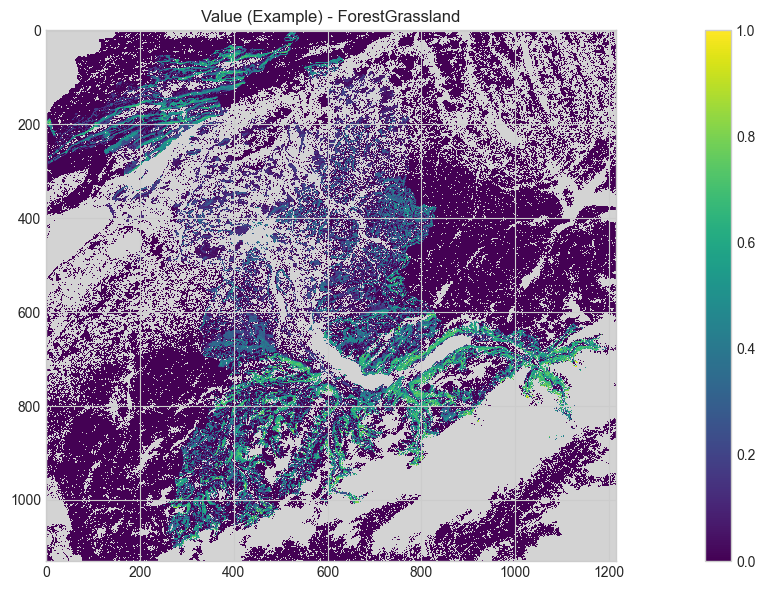

In [7]:
# Define ecosystem types and their LULC codes
ecosystem_types = {
   # 'Forest': [12, 13],
   # 'Grassland': [16, 17],
    'ForestGrassland': [12, 13, 16, 17],
   # 'Agricultural': [15]
}

ecosystem_lulc = initial_conditions['ecosystem_lulc_data']

# Calculate values for each ecosystem type
value_by_ecosystem = {}

for ecosystem_name, lulc_codes in ecosystem_types.items():
    # Create mask for this ecosystem
    ecosystem_mask = np.isin(ecosystem_lulc, lulc_codes)
    
    # Calculate values for this ecosystem
    value = []
    for idx, row in weights.iterrows():
        w1, w2, w3 = row["W1"], row["W2"], row["W3"]
        effect = (
            w1 * normalised_conditions['abiotic_anomaly'] +
            w2 * normalised_conditions['biotic_anomaly'] +
            w3 * normalised_conditions['implementation_cost']
        )
        # Mask to only this ecosystem
        effect_masked = np.where(ecosystem_mask, effect, np.nan)
        value.append(effect_masked)
    
    value_by_ecosystem[ecosystem_name] = value

# Plot one example value raster for each ecosystem
fig, ax = plt.subplots(1, 1, figsize=(18, 6))

for ecosystem_name, value in value_by_ecosystem.items():
    plot_raster(value[0], f'Value (Example) - {ecosystem_name}', ax)

plt.tight_layout()
plt.show()

Note: the area outside of the canton of bern is essentially no data - shows up as zero here.

# Convert to probability of occurence

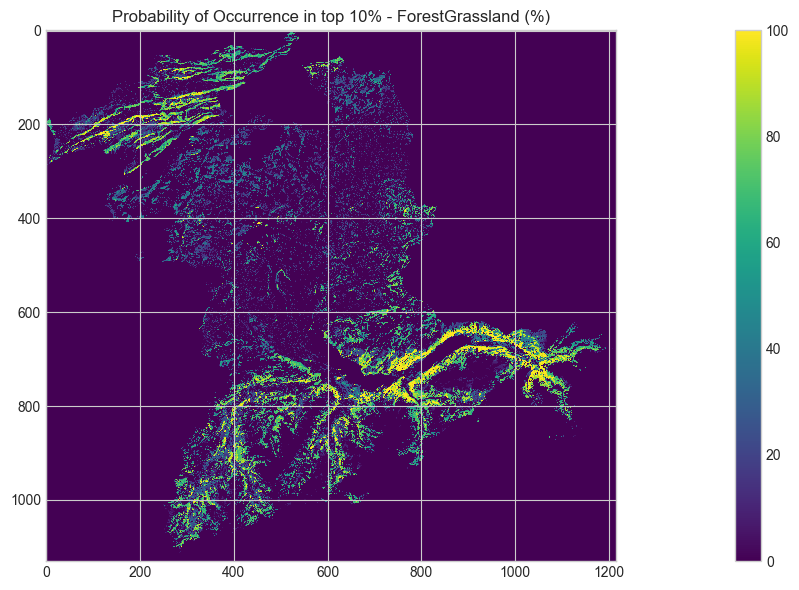

In [8]:
# Calculate probability for each ecosystem type
top_cells_by_ecosystem = {}
prob_by_ecosystem = {}

for ecosystem_name, value in value_by_ecosystem.items():
    # For each value layer, take the 10% highest values and set the rest to na
    top_cells = []
    for layer in value:
        threshold = np.nanpercentile(layer, 90)
        above_threshold = np.where(layer >= threshold, layer, np.nan)
        top_cells.append(above_threshold)
    
    # Calculate the percentage of occurrence of each cell in the 10% highest values
    prob = np.zeros_like(top_cells[0])
    for above_threshold in top_cells:
        prob += np.where(~np.isnan(above_threshold), 1, 0)
    prob /= len(top_cells)
    # Express as a percentage
    prob = prob * 100
    
    top_cells_by_ecosystem[ecosystem_name] = top_cells
    prob_by_ecosystem[ecosystem_name] = prob


# Plot probability for each ecosystem type
fig, ax = plt.subplots(1, 1, figsize=(24, 6))
for idx, (ecosystem_name, prob) in enumerate(prob_by_ecosystem.items()):
    plot_raster(prob, f'Probability of Occurrence in top 10% - {ecosystem_name} (%)', ax)
plt.tight_layout()
plt.show()



# Calculate objective values for these cells

In [ ]:
# Set up effect parameters (matching RestorationProblem defaults)
effect_params = {
    'abiotic_effect': 0.01,
    'biotic_effect': 0.01,
    'neighbor_radius': 3,
    'neighbor_effect_decay': 0.2
}

# Calculate objectives for each ecosystem type
results_by_ecosystem = {}

for ecosystem_name, top_cells in top_cells_by_ecosystem.items():
    # Create binary decision variable arrays from top_cells
    # DV = 1 where cell has a value (is in top 10%), 0 otherwise
    DV = []
    for top_cell_array in top_cells:
        binary = np.where(~np.isnan(top_cell_array), 1, 0)
        DV.append(binary)
    
    # Store results for each solution in this ecosystem
    results = []
    
    for idx, dv_2d in enumerate(DV):
        # Convert 2D decision variable to 1D for eligible restoration pixels only
        # Get indices of restoration-eligible pixels
        restoration_mask = initial_conditions['restoration_eligible_mask']
        restoration_indices = initial_conditions['restoration_eligible_indices']
        
        # Extract restoration decisions for eligible pixels only
        x_restore = dv_2d.flatten()[restoration_indices]
        
        # Don't apply conversion decision - set to zeros
        n_conversion_pixels = initial_conditions['n_conversion_pixels']
        x_convert = np.zeros(n_conversion_pixels, dtype=int)
        
        # Apply restoration effect
        updated_conditions = restoration_effect(x_restore, x_convert, initial_conditions, effect_params)
        
        # Calculate objectives (matching RestorationProblem._evaluate)
        abiotic_base = initial_conditions['abiotic_anomaly']
        abiotic_updated = updated_conditions['abiotic_anomaly']
        abiotic_improvement = np.sum((abiotic_updated - abiotic_base)[restoration_mask])
        abiotic_objective = -abiotic_improvement
        
        biotic_base = initial_conditions['biotic_anomaly']
        biotic_updated = updated_conditions['biotic_anomaly']
        biotic_improvement = np.sum((biotic_updated - biotic_base)[restoration_mask])
        biotic_objective = -biotic_improvement
        
        cost_objective = updated_conditions['implementation_cost']
        
        # Store results
        results.append({
            'solution_id': idx,
            'n_restored_pixels': np.sum(x_restore),
            'abiotic_improvement': abiotic_improvement,
            'biotic_improvement': biotic_improvement,
            'total_cost': cost_objective,
        })
    # Convert to DataFrame
    results_by_ecosystem[ecosystem_name] = pd.DataFrame(results)

# Plot pareto front

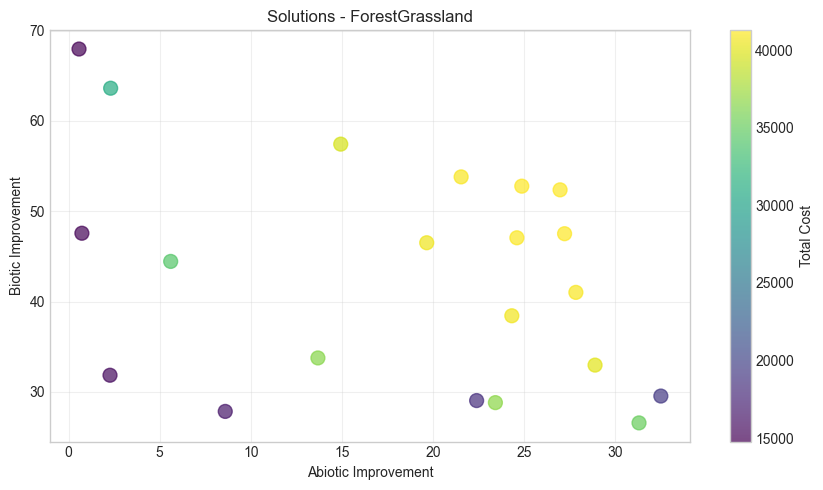

In [ ]:
# Visualize the objective space (Pareto front) for each ecosystem
fig = plt.figure(figsize=(25, 5))

for idx, (ecosystem_name, results_df) in enumerate(results_by_ecosystem.items()):
    ax = fig.add_subplot(1, 3, idx + 1)
    scatter = ax.scatter(results_df['abiotic_improvement'], 
                         results_df['biotic_improvement'],
                         c=results_df['total_cost'],
                         cmap='viridis',
                         s=100,
                         alpha=0.7)
    ax.set_xlabel('Abiotic Improvement')
    ax.set_ylabel('Biotic Improvement')
    ax.set_title(f'Solutions - {ecosystem_name}')
    plt.colorbar(scatter, ax=ax, label='Total Cost')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()